In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Machine learning
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import KNeighborsClassifier

# Visualization (for thesis figures)
import matplotlib.pyplot as plt

In [2]:
data = [
    ["R1", 50, "steel", "permanent", "air", "high_torque"],
    ["R2", 52, "steel", "permanent", "air", "high_torque"],
    ["R3", 30, "aluminum", "none", "passive", "low_power"],
    ["R4", 55, "steel", "permanent", "liquid", "high_torque"],
    ["R5", 28, "aluminum", "none", "passive", "low_power"],
    ["R6", 60, "steel", "induction", "air", "high_speed"],
    ["R7", 58, "steel", "induction", "air", "high_speed"],
    ["R8", 35, "copper", "permanent", "air", "medium"],
    ["R9", 34, "copper", "permanent", "air", "medium"],
    ["R10", 62, "steel", "induction", "liquid", "high_speed"]
]

df = pd.DataFrame(data, columns=[
    "id", "diameter", "material", "magnet", "cooling", "function"
])

print("Dataset:")
display(df)

Dataset:


,id,diameter,material,magnet,cooling,function
0,R1,50,steel,permanent,air,high_torque
1,R2,52,steel,permanent,air,high_torque
2,R3,30,aluminum,none,passive,low_power
3,R4,55,steel,permanent,liquid,high_torque
4,R5,28,aluminum,none,passive,low_power
5,R6,60,steel,induction,air,high_speed
6,R7,58,steel,induction,air,high_speed
7,R8,35,copper,permanent,air,medium
8,R9,34,copper,permanent,air,medium
9,R10,62,steel,induction,liquid,high_speed


In [3]:
df_encoded = pd.get_dummies(df, columns=[
    "material", "magnet", "cooling", "function"
])

df_encoded.set_index("id", inplace=True)

print("Encoded Features:")
display(df_encoded)

Encoded Features:


,diameter,material_aluminum,material_copper,material_steel,magnet_induction,magnet_none,magnet_permanent,cooling_air,cooling_liquid,cooling_passive,function_high_speed,function_high_torque,function_low_power,function_medium
id,,,,,,,,,,,,,,
R1,50,False,False,True,False,False,True,True,False,False,False,True,False,False
R2,52,False,False,True,False,False,True,True,False,False,False,True,False,False
R3,30,True,False,False,False,True,False,False,False,True,False,False,True,False
R4,55,False,False,True,False,False,True,False,True,False,False,True,False,False
R5,28,True,False,False,False,True,False,False,False,True,False,False,True,False
R6,60,False,False,True,True,False,False,True,False,False,True,False,False,False
R7,58,False,False,True,True,False,False,True,False,False,True,False,False,False
R8,35,False,True,False,False,False,True,True,False,False,False,False,False,True
R9,34,False,True,False,False,False,True,True,False,False,False,False,False,True


In [4]:
cos_sim = cosine_similarity(df_encoded)
cos_sim_df = pd.DataFrame(cos_sim, index=df_encoded.index, columns=df_encoded.index)

print("Cosine Similarity:")
display(cos_sim_df)

Cosine Similarity:


id,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10
id,,,,,,,,,,
R1,1.000000,0.999999,0.996988,0.999630,0.996662,0.999312,0.999296,0.998714,0.998650,0.999004
R2,0.999999,1.000000,0.997048,0.999649,0.996722,0.999347,0.999330,0.998730,0.998665,0.999051
R3,0.996988,0.997048,1.000000,0.997126,0.999989,0.997231,0.997192,0.996160,0.996063,0.997266
R4,0.999630,0.999649,0.997126,1.000000,0.996800,0.999087,0.999059,0.998230,0.998148,0.999406
R5,0.996662,0.996722,0.999989,0.996800,1.000000,0.996905,0.996866,0.995834,0.995737,0.996940
R6,0.999312,0.999347,0.997231,0.999087,0.996905,1.000000,0.999999,0.998292,0.998209,0.999731
R7,0.999296,0.999330,0.997192,0.999059,0.996866,0.999999,1.000000,0.998270,0.998187,0.999720
R8,0.998714,0.998730,0.996160,0.998230,0.995834,0.998292,0.998270,1.000000,0.999999,0.997852
R9,0.998650,0.998665,0.996063,0.998148,0.995737,0.998209,0.998187,0.999999,1.000000,0.997755


In [5]:
def semantic_similarity(r1, r2):
    score = 0
    
    if r1["material"] == r2["material"]:
        score += 1
    if r1["magnet"] == r2["magnet"]:
        score += 1
    if r1["cooling"] == r2["cooling"]:
        score += 1
    if r1["function"] == r2["function"]:
        score += 1
        
    return score / 4  # normalize


semantic_matrix = []

for i in range(len(df)):
    row = []
    for j in range(len(df)):
        sim = semantic_similarity(df.iloc[i], df.iloc[j])
        row.append(sim)
    semantic_matrix.append(row)

semantic_df = pd.DataFrame(semantic_matrix, index=df["id"], columns=df["id"])

print("Semantic Similarity:")
display(semantic_df)

Semantic Similarity:


id,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10
id,,,,,,,,,,
R1,1.00,1.00,0.0,0.75,0.0,0.50,0.50,0.50,0.50,0.25
R2,1.00,1.00,0.0,0.75,0.0,0.50,0.50,0.50,0.50,0.25
R3,0.00,0.00,1.0,0.00,1.0,0.00,0.00,0.00,0.00,0.00
R4,0.75,0.75,0.0,1.00,0.0,0.25,0.25,0.25,0.25,0.50
R5,0.00,0.00,1.0,0.00,1.0,0.00,0.00,0.00,0.00,0.00
R6,0.50,0.50,0.0,0.25,0.0,1.00,1.00,0.25,0.25,0.75
R7,0.50,0.50,0.0,0.25,0.0,1.00,1.00,0.25,0.25,0.75
R8,0.50,0.50,0.0,0.25,0.0,0.25,0.25,1.00,1.00,0.00
R9,0.50,0.50,0.0,0.25,0.0,0.25,0.25,1.00,1.00,0.00


In [6]:
alpha = 0.5
beta = 0.5

hybrid_sim = alpha * semantic_df.values + beta * cos_sim_df.values
hybrid_df = pd.DataFrame(hybrid_sim, index=df["id"], columns=df["id"])

print("Hybrid Similarity:")
display(hybrid_df)

Hybrid Similarity:


id,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10
id,,,,,,,,,,
R1,1.000000,0.999999,0.498494,0.874815,0.498331,0.749656,0.749648,0.749357,0.749325,0.624502
R2,0.999999,1.000000,0.498524,0.874824,0.498361,0.749673,0.749665,0.749365,0.749333,0.624526
R3,0.498494,0.498524,1.000000,0.498563,0.999994,0.498616,0.498596,0.498080,0.498032,0.498633
R4,0.874815,0.874824,0.498563,1.000000,0.498400,0.624544,0.624529,0.624115,0.624074,0.749703
R5,0.498331,0.498361,0.999994,0.498400,1.000000,0.498453,0.498433,0.497917,0.497869,0.498470
R6,0.749656,0.749673,0.498616,0.624544,0.498453,1.000000,1.000000,0.624146,0.624105,0.874865
R7,0.749648,0.749665,0.498596,0.624529,0.498433,1.000000,1.000000,0.624135,0.624094,0.874860
R8,0.749357,0.749365,0.498080,0.624115,0.497917,0.624146,0.624135,1.000000,0.999999,0.498926
R9,0.749325,0.749333,0.498032,0.624074,0.497869,0.624105,0.624094,0.999999,1.000000,0.498878


In [7]:
def get_top_k(sim_matrix, rotor_id, k=3):
    scores = sim_matrix[rotor_id].sort_values(ascending=False)
    return scores.iloc[1:k+1]  # exclude itself


print("Top 3 similar rotors to R1 (Hybrid):")
print(get_top_k(hybrid_df, "R1"))

Top 3 similar rotors to R1 (Hybrid):
id
R2    0.999999
R4    0.874815
R6    0.749656
Name: R1, dtype: float64


In [8]:
labels = df["function"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(df_encoded, labels)

predictions = model.predict(df_encoded)

df["predicted_function"] = predictions

print("ML Predictions:")
display(df)

ML Predictions:


,id,diameter,material,magnet,cooling,function,predicted_function
0,R1,50,steel,permanent,air,high_torque,high_torque
1,R2,52,steel,permanent,air,high_torque,high_torque
2,R3,30,aluminum,none,passive,low_power,low_power
3,R4,55,steel,permanent,liquid,high_torque,high_torque
4,R5,28,aluminum,none,passive,low_power,low_power
5,R6,60,steel,induction,air,high_speed,high_speed
6,R7,58,steel,induction,air,high_speed,high_speed
7,R8,35,copper,permanent,air,medium,medium
8,R9,34,copper,permanent,air,medium,medium
9,R10,62,steel,induction,liquid,high_speed,high_speed


In [9]:
def precision_at_k(sim_matrix, df, rotor_id, k=3):
    top_k = get_top_k(sim_matrix, rotor_id, k).index
    true_function = df[df["id"] == rotor_id]["function"].values[0]
    
    correct = 0
    for r in top_k:
        f = df[df["id"] == r]["function"].values[0]
        if f == true_function:
            correct += 1
            
    return correct / k


print("Precision@3 for each rotor (Hybrid):")
for r in df["id"]:
    print(r, precision_at_k(hybrid_df, df, r))

Precision@3 for each rotor (Hybrid):
R1 0.6666666666666666
R2 0.6666666666666666
R3 0.3333333333333333
R4 0.6666666666666666
R5 0.3333333333333333
R6 0.6666666666666666
R7 0.6666666666666666
R8 0.3333333333333333
R9 0.3333333333333333
R10 0.6666666666666666


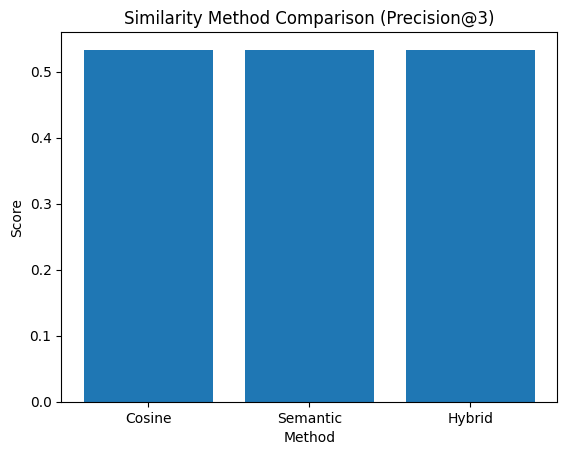

In [10]:
methods = ["Cosine", "Semantic", "Hybrid"]
scores = [
    np.mean([precision_at_k(cos_sim_df, df, r) for r in df["id"]]),
    np.mean([precision_at_k(semantic_df, df, r) for r in df["id"]]),
    np.mean([precision_at_k(hybrid_df, df, r) for r in df["id"]])
]

plt.figure()
plt.bar(methods, scores)
plt.title("Similarity Method Comparison (Precision@3)")
plt.xlabel("Method")
plt.ylabel("Score")
plt.show()